In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import time
from numpy import log1p

In [2]:
cx = pd.read_csv("./data/outputs/symptoms_weekly_user.csv")
llm = pd.read_csv("./data/llm_weekly_user.csv")

print("cx:", cx.shape)
print("llm:", llm.shape)

cx: (16467, 34)
llm: (16336, 9)


In [3]:
cx.head(5)

,user_id,week,valence_w,arousal_w,radius_w,n_posts,anx_score,dep_score,ptsd_score,mania_score,...,empath_health_mean_z,empath_contentment_mean_z,empath_fear_mean_z,empath_trust_mean_z,empath_hate_mean_z,empath_therapy_mean_z,empath_sleep_mean_z,empath_anger_mean_z,empath_shame_mean_z,empath_optimism_mean_z
0,1001,2025-07-14,-0.673745,0.454293,0.826966,3,0.695444,0.315764,0.835437,0.259443,...,0.707331,0.527432,2.035154,-0.767102,0.685984,1.151567,0.087742,-0.441444,0.324786,0.612550
1,1002,2025-07-07,1.621301,-2.060086,2.621559,1,0.200000,0.241136,0.200000,0.241136,...,-0.856687,-0.727392,-0.731852,3.171496,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679
2,1002,2025-07-14,0.746765,-0.075573,1.175629,2,0.200000,0.259128,0.228586,0.287919,...,-0.064543,0.244382,-0.510700,0.205964,-0.679259,0.131225,-0.417312,-0.441444,-0.027287,0.502107
3,1003,2025-07-14,-0.980784,0.515790,1.108141,1,0.403032,0.385207,0.391219,0.291834,...,-0.295585,0.730268,0.834639,-0.767102,1.084869,-0.706984,-0.417312,-0.441444,2.268624,0.575207
4,1004,2023-10-16,-0.085450,0.800728,0.995097,3,0.481419,0.241136,0.350870,0.366142,...,-0.423351,0.166135,-0.284283,-0.130561,-0.511247,-0.230628,-0.417312,-0.178049,0.553874,0.352986


In [4]:
cx.isna().sum()

user_id                      0
week                         0
valence_w                    0
arousal_w                    0
radius_w                     0
n_posts                      0
anx_score                    0
dep_score                    0
ptsd_score                   0
mania_score                  0
sui_score                    0
anx_label                    0
dep_label                    0
ptsd_label                   0
mania_label                  0
sui_label                    0
empath_anxiety_mean_z        0
empath_pain_mean_z           0
empath_violence_mean_z       0
empath_sadness_mean_z        0
empath_depression_mean_z     0
empath_help_mean_z           0
empath_love_mean_z           0
empath_suffering_mean_z      0
empath_health_mean_z         0
empath_contentment_mean_z    0
empath_fear_mean_z           0
empath_trust_mean_z          0
empath_hate_mean_z           0
empath_therapy_mean_z        0
empath_sleep_mean_z          0
empath_anger_mean_z          0
empath_s

In [5]:
cx.columns

Index(['user_id', 'week', 'valence_w', 'arousal_w', 'radius_w', 'n_posts',
       'anx_score', 'dep_score', 'ptsd_score', 'mania_score', 'sui_score',
       'anx_label', 'dep_label', 'ptsd_label', 'mania_label', 'sui_label',
       'empath_anxiety_mean_z', 'empath_pain_mean_z', 'empath_violence_mean_z',
       'empath_sadness_mean_z', 'empath_depression_mean_z',
       'empath_help_mean_z', 'empath_love_mean_z', 'empath_suffering_mean_z',
       'empath_health_mean_z', 'empath_contentment_mean_z',
       'empath_fear_mean_z', 'empath_trust_mean_z', 'empath_hate_mean_z',
       'empath_therapy_mean_z', 'empath_sleep_mean_z', 'empath_anger_mean_z',
       'empath_shame_mean_z', 'empath_optimism_mean_z'],
      dtype='object')

In [6]:
llm.head()

,user_id,week,v_hat_mean,a_hat_mean,r_hat_mean,v_true_mean,a_true_mean,r_true_mean,posts
0,1001,2025-07-14,-0.409809,0.125939,0.481530,-0.615691,0.307426,0.717833,3
1,1002,2025-07-07,0.524243,-2.438016,2.493743,1.198129,-1.814492,2.174372,1
2,1002,2025-07-14,0.015013,0.162249,0.248241,0.807889,0.134938,1.144961,2
3,1003,2025-07-14,-0.508256,0.219530,0.553641,-0.938942,0.285763,0.981464,1
4,1004,2023-10-16,0.201641,0.360576,0.859492,0.139780,0.864974,1.067681,3


In [7]:
keys = ["user_id", "week"]

left = cx.reset_index().merge(
    llm[keys].drop_duplicates(),
    on=keys,
    how="left",
    indicator=True
)

missing = left[left["_merge"] == "left_only"].drop(columns=["_merge"])

print(f"Rows in cx but not in llm: {len(missing)}")
print("Original cx indices for missing rows:", missing["index"].tolist()[:20])
missing.head(20)

Rows in cx but not in llm: 131
Original cx indices for missing rows: [882, 1931, 1975, 2095, 2227, 2699, 3718, 3950, 3972, 4062, 4297, 4298, 4299, 4300, 4303, 4304, 4305, 4306, 4516, 4548]


,index,user_id,week,valence_w,arousal_w,radius_w,n_posts,anx_score,dep_score,ptsd_score,...,empath_health_mean_z,empath_contentment_mean_z,empath_fear_mean_z,empath_trust_mean_z,empath_hate_mean_z,empath_therapy_mean_z,empath_sleep_mean_z,empath_anger_mean_z,empath_shame_mean_z,empath_optimism_mean_z
882,882,1035,2020-10-26,1.223488,1.514760,1.947157,1,0.200000,0.241136,0.200000,...,-0.856687,-0.727392,-0.731852,-0.767102,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679
1931,1931,1051,2025-06-09,1.223488,1.514760,1.947157,1,0.200000,0.241136,0.200000,...,-0.856687,-0.727392,-0.731852,-0.767102,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679
1975,1975,1062,2022-07-11,4.138606,-0.600160,4.181895,1,0.200000,0.241136,0.200000,...,-0.856687,-0.727392,-0.731852,-0.767102,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,7.744636
2095,2095,1077,2025-05-19,1.223488,1.514760,1.947157,1,0.200000,0.241136,0.200000,...,-0.856687,-0.727392,-0.731852,-0.767102,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679
2227,2227,1082,2021-01-11,1.223488,1.514760,1.947157,1,0.200000,0.241136,0.200000,...,-0.856687,-0.727392,-0.731852,-0.767102,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679
2699,2699,1116,2020-12-07,1.223488,1.514760,1.947157,1,0.200000,0.241136,0.200000,...,-0.856687,-0.727392,-0.731852,-0.767102,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679
3718,3718,1165,2022-10-31,3.023427,-1.689186,3.463301,1,0.200000,0.241136,0.200000,...,-0.856687,-0.727392,-0.731852,13.017989,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679
3950,3950,1226,2025-03-03,-0.294721,-0.518088,0.596050,1,0.200022,0.552600,0.400089,...,-0.856687,-0.727392,-0.731852,-0.767102,13.433767,-0.706984,22.815179,-0.441444,-0.862163,10.612408
3972,3972,1234,2024-05-27,1.223488,1.514760,1.947157,1,0.200000,0.241136,0.200000,...,-0.856687,-0.727392,-0.731852,-0.767102,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679
4062,4062,1251,2025-02-03,-2.037270,3.329804,3.903596,1,0.400000,0.241136,0.200000,...,-0.856687,-0.727392,-0.731852,-0.767102,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679


The reason we lost 131 rows of data from llm(llm_weekly_user) is because we filtered token>5 from Mental RoBERTa pipeline.

In [8]:
cx = cx.rename(columns={
    "valence_z_mean": "v_true_mean",
    "arousal_z_mean": "a_true_mean",
    "radius_z_mean": "r_true_mean",
    "n_posts": "posts_true"
})

cx["week"] = pd.to_datetime(cx["week"])
llm["week"] = pd.to_datetime(llm["week"])

In [ ]:
merged = pd.merge(cx, llm, on=["user_id", "week"], how="inner").sort_values(by=["user_id", "week"]).reset_index(drop=True)

def compute_days_since_event(event_series):
    """Compute weeks since last True event """
    result = []
    last_event = -999
    for i, is_event in enumerate(event_series):
        if is_event:
            last_event = i
            result.append(1)
        else:
            result.append(i - last_event + 1)
    return pd.Series(result, index=event_series.index)

def safe_qcut(s, q=4, labels=None):
    """ helper because qcut crashes when all values identical"""
    if labels is None:
        labels = list(range(q))
    try:
        # Use duplicates drop to avoid failure on identical values
        return pd.qcut(s, q=q, labels=labels, duplicates="drop")
    except Exception:
        if s.nunique() <= 1:
            return pd.Series([float(labels[len(labels)//2])] * len(s), index=s.index)
        ranks = s.rank(method="min")
        ranks = (ranks - ranks.min()) / (ranks.max() - ranks.min() + 1e-8)
        bins = pd.cut(ranks, bins=q, labels=labels)
        return bins


if {"v_hat_mean", "a_hat_mean"}.issubset(merged.columns):
    merged["v_gap"] = merged["v_true_mean"] - merged["v_hat_mean"]
    merged["a_gap"] = merged["a_true_mean"] - merged["a_hat_mean"]

    for prefix in ["v", "a"]:
        gap_col = f"{prefix}_gap"
        
        # Only keep the most robust gap features
        merged[f"{prefix}_gap_abs"] = np.abs(merged[gap_col])  # Magnitude
        merged[f"{prefix}_gap_rank"] = (merged.groupby("user_id")[gap_col]
                                       .rank(pct=True)
                                       .reset_index(level=0, drop=True))  # Always 0-1
        merged[f"{prefix}_gap_zscore"] = ((merged[gap_col] - merged.groupby("user_id")[gap_col].transform("mean")) / 
                                         (merged.groupby("user_id")[gap_col].transform("std").fillna(1.0) + 1e-6))
        
        
symptom_cols = ["anx_score", "dep_score", "ptsd_score", "mania_score", "sui_score"]

print("\n=== SYMPTOM SCORE ANALYSIS ===")
for col in symptom_cols:
    if col in merged.columns:
        print(f"{col}:")
        print(f"  Range: {merged[col].min():.3f} to {merged[col].max():.3f}")
        print(f"  Mean: {merged[col].mean():.3f}, Std: {merged[col].std():.3f}")
        print(f"  % above 0.5: {(merged[col] > 0.5).mean()*100:.1f}%")
        
        # Create symptom change features
        merged[f"{col}_delta"] = merged.groupby("user_id")[col].diff().fillna(0.0)
        
        # Symptom momentum 
        merged[f"{col}_momentum"] = (merged.groupby("user_id")[f"{col}_delta"]
                                   .rolling(3, min_periods=1).mean()
                                   .reset_index(level=0, drop=True))
        
        # Above 75th percentile
        threshold = merged[col].quantile(0.75)
        merged[f"{col}_high"] = (merged[col] > threshold).astype(float)
        
        # Time since high symptom episode
        high_episodes = merged[f"{col}_high"] == 1
        merged[f"{col}_weeks_since_high"] = (merged.groupby("user_id", group_keys=False)
                                           .apply(lambda x: compute_days_since_event(high_episodes.loc[x.index])))

print(f"\nCreated {len(symptom_cols) * 4} symptom-derived features")

base_columns = ["v_true_mean", "a_true_mean"]
if {"v_hat_mean", "a_hat_mean"}.issubset(merged.columns):
    base_columns.extend(["v_hat_mean", "a_hat_mean"])

for c in base_columns:
    # Robust delta
    merged[f"{c}_delta"] = merged.groupby("user_id")[c].diff().fillna(0.0)
    
    # EMA 
    merged[f"{c}_ema3"] = (merged.groupby("user_id")[c]
                          .apply(lambda s: s.ewm(alpha=0.3, adjust=False).mean())
                          .reset_index(level=0, drop=True))
    
    # Trend over 4 weeks 
    merged[f"{c}_trend4"] = (merged.groupby("user_id")[c]
                            .rolling(4, min_periods=2)
                            .apply(lambda x: np.polyfit(range(len(x)), x, 1)[0] if len(x) > 1 else 0.0)
                            .reset_index(level=0, drop=True)
                            .fillna(0.0))
    
    # Within-user percentile rank 
    merged[f"{c}_rank"] = (merged.groupby("user_id")[c]
                          .rank(pct=True)
                          .reset_index(level=0, drop=True))

    # Standardized
    user_mean = merged.groupby("user_id")[c].transform("mean")
    user_std = merged.groupby("user_id")[c].transform("std").fillna(1.0)
    merged[f"{c}_zscore"] = (merged[c] - user_mean) / (user_std + 1e-6)

print(f"\nCreated {len(base_columns) * 5} robust derived features")

for c in ["v_true_mean","a_true_mean"]:
    merged[f"{c}_ema3"] = (merged
        .groupby("user_id")[c]
        .apply(lambda s: s.ewm(alpha=0.5, adjust=False).mean())
        .reset_index(level=0, drop=True))


print("merged:", merged.shape)

print("\n=== GAP FEATURE ANALYSIS ===")
for prefix in ["v", "a"]:
    if f"{prefix}_gap" in merged.columns:
        print(f"\n{prefix.upper()}_gap features:")
        new_features = [
            f"{prefix}_gap_magnitude",
            f"{prefix}_gap_zscore",
            f"{prefix}_gap_percentile",
            f"{prefix}_days_since_extreme",
            f"{prefix}_gap_trend_6week",
        ]
        for feat in new_features:
            if feat in merged.columns:
                zeros = (merged[feat] == 0.0).sum()
                print(f"  {feat}: {zeros:5} zeros ({zeros/len(merged)*100:4.1f}%)")


=== SYMPTOM SCORE ANALYSIS ===
anx_score:
  Range: 0.200 to 1.066
  Mean: 0.335, Std: 0.189
  % above 0.5: 17.0%


/var/folders/0l/qgn1vqn15c3gw9rx0_bhcwq40000gn/T/ipykernel_17232/1521271202.py:72: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: compute_days_since_event(high_episodes.loc[x.index])))


dep_score:
  Range: 0.200 to 1.103
  Mean: 0.291, Std: 0.106
  % above 0.5: 4.1%


/var/folders/0l/qgn1vqn15c3gw9rx0_bhcwq40000gn/T/ipykernel_17232/1521271202.py:72: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: compute_days_since_event(high_episodes.loc[x.index])))


ptsd_score:
  Range: 0.200 to 1.176
  Mean: 0.356, Std: 0.199
  % above 0.5: 19.5%


...

mania_score:
  Range: 0.200 to 1.049
  Mean: 0.266, Std: 0.084
  % above 0.5: 2.4%


/var/folders/0l/qgn1vqn15c3gw9rx0_bhcwq40000gn/T/ipykernel_17232/1521271202.py:72: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: compute_days_since_event(high_episodes.loc[x.index])))


sui_score:
  Range: 0.200 to 1.160
  Mean: 0.382, Std: 0.152
  % above 0.5: 12.9%


/var/folders/0l/qgn1vqn15c3gw9rx0_bhcwq40000gn/T/ipykernel_17232/1521271202.py:72: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: compute_days_since_event(high_episodes.loc[x.index])))



Created 20 symptom-derived features

Created 20 robust derived features
merged: (16336, 89)

=== GAP FEATURE ANALYSIS ===

V_gap features:
  v_gap_zscore:  4490 zeros (27.5%)

A_gap features:
  a_gap_zscore:  4490 zeros (27.5%)


In [10]:
print("\nSymptom score correlations:")
symptom_corr = merged[symptom_cols].corr()
print(symptom_corr.round(3))

print("\nHigh symptom episode rates:")
for col in symptom_cols:
    high_rate = merged[f"{col}_high"].mean()
    print(f"  {col}_high: {high_rate:.1%}")


Symptom score correlations:
             anx_score  dep_score  ptsd_score  mania_score  sui_score
anx_score        1.000     -0.009       0.886       -0.021      0.179
dep_score       -0.009      1.000       0.059       -0.060      0.557
ptsd_score       0.886      0.059       1.000       -0.058      0.364
mania_score     -0.021     -0.060      -0.058        1.000     -0.107
sui_score        0.179      0.557       0.364       -0.107      1.000

High symptom episode rates:
  anx_score_high: 25.0%
  dep_score_high: 25.0%
  ptsd_score_high: 25.0%
  mania_score_high: 25.0%
  sui_score_high: 25.0%


In [11]:
merged.head(10)

,user_id,week,valence_w,arousal_w,radius_w,posts_true,anx_score,dep_score,ptsd_score,mania_score,...,v_hat_mean_delta,v_hat_mean_ema3,v_hat_mean_trend4,v_hat_mean_rank,v_hat_mean_zscore,a_hat_mean_delta,a_hat_mean_ema3,a_hat_mean_trend4,a_hat_mean_rank,a_hat_mean_zscore
0,1001,2025-07-14,-0.673745,0.454293,0.826966,3,0.695444,0.315764,0.835437,0.259443,...,0.000000,-0.409809,0.000000,1.0,0.000000,0.000000,0.125939,0.000000,1.0,0.000000
1,1002,2025-07-07,1.621301,-2.060086,2.621559,1,0.200000,0.241136,0.200000,0.241136,...,0.000000,0.524243,0.000000,1.0,0.707105,0.000000,-2.438016,0.000000,0.5,-0.707106
2,1002,2025-07-14,0.746765,-0.075573,1.175629,2,0.200000,0.259128,0.228586,0.287919,...,-0.509230,0.371474,-0.509230,0.5,-0.707105,2.600265,-1.657936,2.600265,1.0,0.707106
3,1003,2025-07-14,-0.980784,0.515790,1.108141,1,0.403032,0.385207,0.391219,0.291834,...,0.000000,-0.508256,0.000000,1.0,0.000000,0.000000,0.219530,0.000000,1.0,0.000000
4,1004,2023-10-16,-0.085450,0.800728,0.995097,3,0.481419,0.241136,0.350870,0.366142,...,0.000000,0.201641,0.000000,0.8,0.761947,0.000000,0.360576,0.000000,0.8,0.554791
5,1004,2023-10-30,-0.626543,0.036339,0.630769,2,0.235782,0.464686,0.417857,0.217332,...,-0.515673,0.046939,-0.515673,0.2,-1.112121,-0.332501,0.260826,-0.332501,0.5,-0.241130
6,1004,2023-11-06,-0.346843,-0.152407,0.382682,2,0.206100,0.368491,0.255167,0.200018,...,0.137369,-0.020142,-0.189152,0.4,-0.612891,-0.131283,0.151616,-0.231892,0.3,-0.555386
7,1004,2024-01-08,-0.922091,1.406471,1.681789,1,0.389889,0.327906,0.395904,0.241136,...,-0.071071,-0.088419,-0.121076,0.3,-0.871178,0.777531,0.308429,0.080996,0.9,1.305821
8,1004,2024-02-05,-0.888179,0.228973,0.917219,1,0.366538,0.387937,0.330048,0.241136,...,-0.099409,-0.166037,-0.017040,0.1,-1.232452,-0.517609,0.262915,0.116345,0.6,0.066801
9,1004,2024-02-12,-0.685654,0.703329,0.982239,1,0.551684,0.255111,0.570745,0.247379,...,0.249976,-0.145376,0.013908,0.5,-0.323987,0.112470,0.264796,0.059957,0.7,0.336023


In [12]:
merged.isna().sum()

user_id              0
week                 0
valence_w            0
arousal_w            0
radius_w             0
                    ..
a_hat_mean_delta     0
a_hat_mean_ema3      0
a_hat_mean_trend4    0
a_hat_mean_rank      0
a_hat_mean_zscore    0
Length: 89, dtype: int64

In [13]:
merged.columns

Index(['user_id', 'week', 'valence_w', 'arousal_w', 'radius_w', 'posts_true',
       'anx_score', 'dep_score', 'ptsd_score', 'mania_score', 'sui_score',
       'anx_label', 'dep_label', 'ptsd_label', 'mania_label', 'sui_label',
       'empath_anxiety_mean_z', 'empath_pain_mean_z', 'empath_violence_mean_z',
       'empath_sadness_mean_z', 'empath_depression_mean_z',
       'empath_help_mean_z', 'empath_love_mean_z', 'empath_suffering_mean_z',
       'empath_health_mean_z', 'empath_contentment_mean_z',
       'empath_fear_mean_z', 'empath_trust_mean_z', 'empath_hate_mean_z',
       'empath_therapy_mean_z', 'empath_sleep_mean_z', 'empath_anger_mean_z',
       'empath_shame_mean_z', 'empath_optimism_mean_z', 'v_hat_mean',
       'a_hat_mean', 'r_hat_mean', 'v_true_mean', 'a_true_mean', 'r_true_mean',
       'posts', 'v_gap', 'a_gap', 'v_gap_abs', 'v_gap_rank', 'v_gap_zscore',
       'a_gap_abs', 'a_gap_rank', 'a_gap_zscore', 'anx_score_delta',
       'anx_score_momentum', 'anx_score_high',

In [52]:
merged['user_id'].nunique()

6262

In [14]:
df = merged.sort_values(["user_id","week"]).copy()

df["v_next"] = df.groupby("user_id")["v_true_mean"].shift(-1)
df["a_next"] = df.groupby("user_id")["a_true_mean"].shift(-1)
# DELTA targets
df["dv_target"] = df["v_next"] - df["v_true_mean"]
df["da_target"] = df["a_next"] - df["a_true_mean"]

sym_cols = ["anx_label","dep_label","ptsd_label","mania_label","sui_label"]
for c in sym_cols:
    df[c + "_next"] = df.groupby("user_id")[c].shift(-1)



TARGET = ["dv_target","da_target"]

symptom_feats = []
for col in symptom_cols:
    if col in df.columns:
        symptom_feats.extend([
            col, f"{col}_delta", f"{col}_momentum", 
            f"{col}_high", f"{col}_weeks_since_high"
        ])

circ_feats = [
    "v_true_mean", "a_true_mean", "r_true_mean",
    "v_true_mean_delta", "a_true_mean_delta",
    "v_true_mean_ema3", "a_true_mean_ema3", 
    "v_true_mean_trend4", "a_true_mean_trend4",
    "v_true_mean_rank", "a_true_mean_rank",
    "v_true_mean_zscore", "a_true_mean_zscore",
    "posts"
]

roberta_feats = []
if {"v_hat_mean","a_hat_mean"}.issubset(df.columns):
    roberta_feats = [
        "v_hat_mean", "a_hat_mean",
        "v_hat_mean_delta", "a_hat_mean_delta",
        "v_hat_mean_ema3", "a_hat_mean_ema3",
        "v_hat_mean_rank", "a_hat_mean_rank", 
        "v_gap", "a_gap",
        "v_gap_abs", "a_gap_abs",
        "v_gap_rank", "a_gap_rank",
        "v_gap_zscore", "a_gap_zscore",
        "posts"
    ]

fusion_feats = circ_feats + [f for f in roberta_feats if f not in {"posts"}] + symptom_feats

print(f"Feature counts:")
print(f"  Circumplex: {len(circ_feats)}")
print(f"  RoBERTa: {len(roberta_feats)}")  
print(f"  Symptoms: {len(symptom_feats)}")
print(f"  Total fusion: {len(fusion_feats)}")

df

Feature counts:
  Circumplex: 14
  RoBERTa: 17
  Symptoms: 25
  Total fusion: 55


,user_id,week,valence_w,arousal_w,radius_w,posts_true,anx_score,dep_score,ptsd_score,mania_score,...,a_hat_mean_zscore,v_next,a_next,dv_target,da_target,anx_label_next,dep_label_next,ptsd_label_next,mania_label_next,sui_label_next
0,1001,2025-07-14,-0.673745,0.454293,0.826966,3,0.695444,0.315764,0.835437,0.259443,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1002,2025-07-07,1.621301,-2.060086,2.621559,1,0.200000,0.241136,0.200000,0.241136,...,-0.707106,0.807889,0.134938,-0.390240,1.949430,0.0,0.0,0.0,0.0,0.0
2,1002,2025-07-14,0.746765,-0.075573,1.175629,2,0.200000,0.259128,0.228586,0.287919,...,0.707106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1003,2025-07-14,-0.980784,0.515790,1.108141,1,0.403032,0.385207,0.391219,0.291834,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1004,2023-10-16,-0.085450,0.800728,0.995097,3,0.481419,0.241136,0.350870,0.366142,...,0.554791,-0.685762,-0.143300,-0.825542,-1.008274,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16331,7317,2020-06-15,1.210173,-0.640604,2.095708,2,0.200000,0.216622,0.200000,0.216622,...,-0.707106,0.397774,-0.101347,-0.759545,0.255896,0.0,0.0,0.0,0.0,0.0
16332,7317,2020-07-13,0.410472,-0.199447,0.456363,1,0.200016,0.284580,0.200014,0.252476,...,0.707106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16333,7318,2020-06-22,0.580822,0.066313,0.584596,1,0.200025,0.241136,0.301759,0.320649,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16334,7319,2020-07-06,-0.826631,0.920268,1.237017,1,0.289251,0.343217,0.465705,0.241138,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The NaN value is from the last week of each user because there is no next week after the last week. We will handle this problem in the build_sequence() function.

In [ ]:
LAG = 1                 # predict 1 week ahead
HIST_L = 3
MIN_WEEKS_PER_USER = HIST_L + LAG

counts = df.groupby("user_id").size()
eligible = counts[counts >= MIN_WEEKS_PER_USER].index
df = df[df["user_id"].isin(eligible)]

def build_sequences(df, feats, target, hist_l, lag=1):
    """ build (X,y,y_last) sequences per user, handles NaNs and variable lengths"""
    X_list, y_list, y_last_list, uid_list, endweek_list = [], [], [], [], []

    g = df.groupby("user_id", sort=False)
    for uid, sub in g:
        sub = sub.sort_values("week")
        feat_mat = sub[feats].to_numpy(dtype=np.float32)     # (T, F)
        targ_mat = sub[target].to_numpy(dtype=np.float32)    # (T, 2)  (dv_target, da_target)
        v_arr = sub["v_true_mean"].to_numpy(dtype=np.float32)
        a_arr = sub["a_true_mean"].to_numpy(dtype=np.float32)
        weeks = pd.to_datetime(sub["week"]).to_numpy()

        if len(sub) < hist_l + lag:
            continue

        # window ends at t-1, predict t (lag=1)
        for t in range(hist_l, len(sub) - lag + 1):
            target_values = targ_mat[t+lag-1, :]
            if np.any(np.isnan(target_values)):
                continue
            X_win = feat_mat[t-hist_l:t, :]          # Features from t-hist_l to t-1
            y_delta = targ_mat[t+lag-1, :]           # Target at t+lag-1 (future)
            v_last_true = v_arr[t-1]                 # Last V at end of history window
            a_last_true = a_arr[t-1]                 # Last A at end of history window

            X_list.append(X_win)
            y_list.append(y_delta)
            y_last_list.append(np.array([v_last_true, a_last_true], np.float32))
            uid_list.append(uid)
            endweek_list.append(weeks[t-1])

    X = np.stack(X_list, axis=0) if X_list else np.zeros((0, hist_l, len(feats)), np.float32)
    y = np.stack(y_list,  axis=0) if y_list  else np.zeros((0, 2), np.float32)
    y_last = np.stack(y_last_list, axis=0) if y_last_list else np.zeros((0, 2), np.float32)
    meta = pd.DataFrame({"user_id": uid_list, "end_week": endweek_list})
    return X, y, y_last, meta

X_all, y_all, y_last_all, meta = build_sequences(df, fusion_feats, TARGET, HIST_L, LAG)
X_all.shape, y_all.shape, y_last_all.shape, meta.shape

((6820, 3, 55), (6820, 2), (6820, 2), (6820, 2))

In [ ]:
print("=== DATA VALIDATION ===")
print(f"Total rows in df: {len(df)}")
print(f"Rows with NaN dv_target: {df['dv_target'].isna().sum()}")
print(f"Rows with NaN da_target: {df['da_target'].isna().sum()}")

# Count valid sequences per user
valid_targets = ~(df['dv_target'].isna() | df['da_target'].isna())
print(f"Rows with valid targets: {valid_targets.sum()}")

# Check how many users have enough data
user_valid_counts = df[valid_targets].groupby('user_id').size()
users_with_min_data = user_valid_counts[user_valid_counts >= MIN_WEEKS_PER_USER]
print(f"Users with >= {MIN_WEEKS_PER_USER} valid weeks: {len(users_with_min_data)}")

sample_user = df[df['user_id'] == df['user_id'].iloc[0]].sort_values('week')
print(f"\nSample user {sample_user['user_id'].iloc[0]} data:")
print(sample_user[['week', 'v_true_mean', 'a_true_mean', 'v_next', 'a_next', 'dv_target', 'da_target']].head(10))

=== DATA VALIDATION ===
Total rows in df: 9128
Rows with NaN dv_target: 577
Rows with NaN da_target: 577
Rows with valid targets: 8551
Users with >= 4 valid weeks: 436

Sample user 1004 data:
         week  v_true_mean  a_true_mean    v_next    a_next  dv_target  \
4  2023-10-16     0.139780     0.864974 -0.685762 -0.143300  -0.825542   
5  2023-10-30    -0.685762    -0.143300 -0.430206 -0.271092   0.255556   
6  2023-11-06    -0.430206    -0.271092 -0.612570  1.292982  -0.182364   
7  2024-01-08    -0.612570     1.292982 -0.920099 -0.005890  -0.307528   
8  2024-02-05    -0.920099    -0.005890 -0.555915  0.580744   0.364184   
9  2024-02-12    -0.555915     0.580744 -0.446960  0.193147   0.108954   
10 2025-06-09    -0.446960     0.193147 -0.332212  0.432463   0.114748   
11 2025-06-16    -0.332212     0.432463 -0.489554  0.849807  -0.157342   
12 2025-06-30    -0.489554     0.849807  0.055242 -1.386328   0.544796   
13 2025-07-14     0.055242    -1.386328       NaN       NaN        N

In [ ]:
# simple user shuffle
rng = np.random.default_rng(42)
uids = meta["user_id"].unique().tolist()
rng.shuffle(uids)
n = len(uids); n_test = int(0.20*n); n_val = int(0.10*(n-n_test))
test_u = set(uids[:n_test]); val_u = set(uids[n_test:n_test+n_val]); train_u = set(uids[n_test+n_val:])

idx_tr = meta["user_id"].isin(train_u).values
idx_va = meta["user_id"].isin(val_u).values
idx_te = meta["user_id"].isin(test_u).values

X_tr,  y_tr,  y_last_tr  = X_all[idx_tr], y_all[idx_tr], y_last_all[idx_tr]
X_va,  y_va,  y_last_va  = X_all[idx_va], y_all[idx_va], y_last_all[idx_va]
X_te,  y_te,  y_last_te  = X_all[idx_te], y_all[idx_te], y_last_all[idx_te]

mu_X = X_tr.mean(axis=(0,1), keepdims=True)
sd_X = X_tr.std(axis=(0,1), keepdims=True) + 1e-6
X_tr = (X_tr - mu_X) / sd_X
X_va = (X_va - mu_X) / sd_X
X_te = (X_te - mu_X) / sd_X

sd_y = y_tr.std(axis=0, keepdims=True) + 1e-6
y_tr = y_tr / sd_y
y_va = y_va / sd_y
y_te = y_te / sd_y

print("train", X_tr.shape, "val", X_va.shape, "test", X_te.shape)

train (5465, 3, 55) val (405, 3, 55) test (950, 3, 55)


=== DATA ANALYSIS ===
Raw delta targets stats:
  dv_target: mean=0.0069, std=0.9989
  da_target: mean=-0.0058, std=0.9853
Scaled targets stats:
  y_tr: mean=[-0.00153762  0.00291715], std=[0.99999875 0.99999875]
Target distributions:
  dv_target percentiles: [nan nan nan nan nan]
  da_target percentiles: [nan nan nan nan nan]


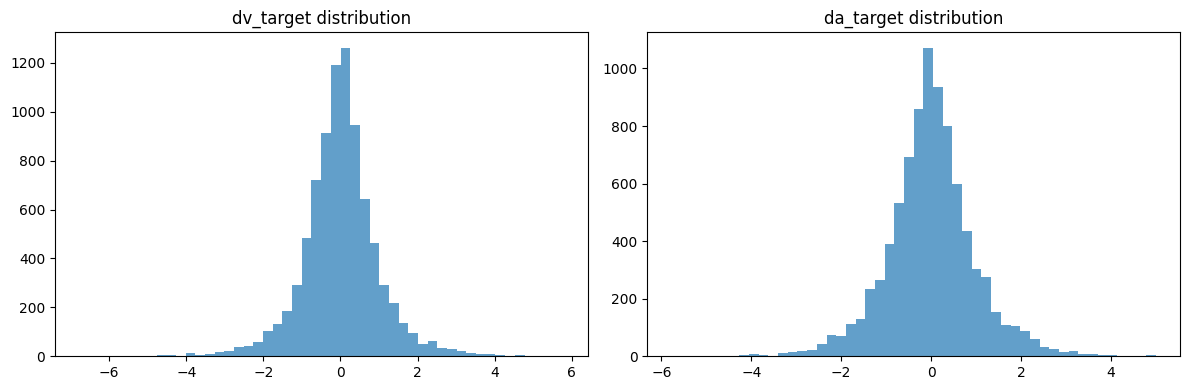

In [18]:
# Add after data loading
print("=== DATA ANALYSIS ===")
print(f"Raw delta targets stats:")
print(f"  dv_target: mean={df['dv_target'].mean():.4f}, std={df['dv_target'].std():.4f}")
print(f"  da_target: mean={df['da_target'].mean():.4f}, std={df['da_target'].std():.4f}")

print(f"Scaled targets stats:")
print(f"  y_tr: mean={y_tr.mean(axis=0)}, std={y_tr.std(axis=0)}")

print(f"Target distributions:")
print(f"  dv_target percentiles: {np.percentile(df['dv_target'], [5, 25, 50, 75, 95])}")
print(f"  da_target percentiles: {np.percentile(df['da_target'], [5, 25, 50, 75, 95])}")

# Check for class imbalance in targets
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['dv_target'], bins=50, alpha=0.7)
axes[0].set_title('dv_target distribution')
axes[1].hist(df['da_target'], bins=50, alpha=0.7)
axes[1].set_title('da_target distribution')
plt.tight_layout()
plt.show()

In [ ]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))

param_grid = {
    'hidden_size': [64, 128, 256],
    'num_layers':  [1, 2, 3],
    'dropout':     [0.1, 0.15, 0.2],
    'learning_rate': [1e-3, 2e-3, 5e-3],
}
EPOCHS   = 50
PATIENCE = 7
BATCH_TR = 64
BATCH_EVAL = 128
WD       = 1e-4
CORR_W   = 0.05

rng_seed = 42
np.random.seed(rng_seed); torch.manual_seed(rng_seed)

# helpers
def fidx(name, feat_list):
    try:
        return feat_list.index(name)
    except ValueError:
        raise ValueError(f"{name} not found in features: {feat_list[:8]} ...")
    
def pick_base_names(feature_names):
    if "v_true_mean" in feature_names and "a_true_mean" in feature_names:
        return "v_true_mean", "a_true_mean"
    elif "v_hat_mean" in feature_names and "a_hat_mean" in feature_names:
        return "v_hat_mean", "a_hat_mean"
    else:
        raise ValueError("Couldn't find base valence/arousal names in feature list.")


def make_loader(X, y_delta, y_last, batch=64, shuffle=True):
    ds = TensorDataset(
        torch.from_numpy(X).float(),
        torch.from_numpy(y_delta).float(),
        torch.from_numpy(y_last).float(),
    )
    return DataLoader(ds, batch_size=batch, shuffle=shuffle)


train_dl = make_loader(X_tr, y_tr, y_last_tr, batch=64, shuffle=True)
val_dl   = make_loader(X_va, y_va, y_last_va, batch=128, shuffle=False)
test_dl  = make_loader(X_te, y_te, y_last_te, batch=128, shuffle=False)

class LSTM(nn.Module):
    def __init__(self, d_in, hidden_size=128, num_layers=2, dropout=0.15):
        super().__init__()
        
        #  try a simple input projection
        self.input_proj = nn.Sequential(
            nn.Linear(d_in, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # LSTM
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        
        # attention layer
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size * 2,
            num_heads=8,  # Increased heads
            dropout=dropout,
            batch_first=True
        )
        
        # Layer normalization
        self.norm1 = nn.LayerNorm(hidden_size * 2)
        self.norm2 = nn.LayerNorm(hidden_size * 2)
        
        self.head = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2),
            nn.ReLU(), 
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 2)
        )
        
        self.aux_head = nn.Linear(hidden_size * 2, 2)
        
    def forward(self, x, return_aux=False):
        # Input projection
        x_proj = self.input_proj(x)  # (B, T, H)
        
        # LSTM processing
        lstm_out, _ = self.lstm(x_proj)  # (B, T, H*2)
        
        # Self-attention with residual
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        lstm_out = self.norm1(lstm_out + attn_out)
        
        # weighted combination of last and mean
        last_hidden = lstm_out[:, -1, :]  # (B, H*2)
        mean_hidden = lstm_out.mean(dim=1)  # (B, H*2)
        
        # Learnable combination weights
        combined = 0.7 * last_hidden + 0.3 * mean_hidden
        combined = self.norm2(combined)
        
        # Main prediction
        main_pred = self.head(combined)
        
        if return_aux:
            aux_pred = self.aux_head(combined)
            return main_pred, aux_pred
        
        return main_pred

In [ ]:
def scale_split(X_tr, X_va, X_te, y_tr, y_va, y_te):
    # feature scaler 
    mu_X = X_tr.mean(axis=(0,1), keepdims=True)
    sd_X = X_tr.std(axis=(0,1), keepdims=True) + 1e-6
    X_trs = (X_tr - mu_X)/sd_X
    X_vas = (X_va - mu_X)/sd_X
    X_tes = (X_te - mu_X)/sd_X
    # target scaler 
    sd_y = y_tr.std(axis=0, keepdims=True) + 1e-6
    y_trs = y_tr / sd_y; y_vas = y_va / sd_y; y_tes = y_te / sd_y
    return (X_trs, X_vas, X_tes, y_trs, y_vas, y_tes, sd_y)

def eval_loader(dl, model, sd_y_np, device):
    model.eval()
    yp_list, yt_list = [], []
    sd_y_t = torch.from_numpy(sd_y_np).to(device).float()
    with torch.no_grad():
        for xb, yb_delta, yb_last in dl:
            xb = xb.to(device); yb_delta = yb_delta.to(device); yb_last = yb_last.to(device)
            d_pred = model(xb)
            d_pred = d_pred * sd_y_t
            yb_delta = yb_delta * sd_y_t
            y_next_pred = yb_last + d_pred
            y_next_true = yb_last + yb_delta
            yp_list.append(y_next_pred.detach().cpu().numpy())
            yt_list.append(y_next_true.detach().cpu().numpy())

    yp = np.vstack(yp_list); yt = np.vstack(yt_list)
    mae_v = np.mean(np.abs(yt[:,0] - yp[:,0]))
    mae_a = np.mean(np.abs(yt[:,1] - yp[:,1]))
    r_v   = np.corrcoef(yt[:,0], yp[:,0])[0,1] if len(yt)>2 else np.nan
    r_a   = np.corrcoef(yt[:,1], yp[:,1])[0,1] if len(yt)>2 else np.nan
    return {"mae_valence": mae_v, "mae_arousal": mae_a, "r_valence": r_v, "r_arousal": r_a}

def val_score(m):
    # lower is better
    return (m["mae_valence"] + m["mae_arousal"]) - 0.10*(m["r_valence"] + m["r_arousal"])

def corr_loss(y_pred, y_true, eps=1e-8):
    # y_* shape: (B,2)
    losses=[]
    for j in range(2):
        yp = y_pred[:,j] - y_pred[:,j].mean()
        yt = y_true[:,j] - y_true[:,j].mean()
        num = (yp*yt).sum()
        den = torch.sqrt((yp**2).sum()+eps)*torch.sqrt((yt**2).sum()+eps) + eps
        losses.append(1.0 - num/den)
    return sum(losses)/2

In [ ]:
results = []
grid = list(itertools.product(param_grid['hidden_size'],
                              param_grid['num_layers'],
                              param_grid['dropout'],
                              param_grid['learning_rate']))

print(f"Grid size: {len(grid)} combos")

best = {"score": float("inf"), "state": None, "epoch": 0}
patience_counter = 0
max_patience = 10

for (hs, nl, dp, lr) in grid:
    t0 = time.time()
    # Re-seed for reproducibility per trial
    np.random.seed(rng_seed); torch.manual_seed(rng_seed)
    
    # Initialize model, optimizer, scheduler
    model = LSTM(d_in=len(fusion_feats), hidden_size=hs, num_layers=nl, dropout=dp).to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.MSELoss()
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.7, patience=3)

    train_losses = []
    val_maes_v, val_maes_a = [], []
    val_corrs_v, val_corrs_a = [], []
    val_scores = []

    # Scale per trial
    Xtr, Xva, Xte, ytr, yva, yte, sd_y = scale_split(X_tr, X_va, X_te, y_tr, y_va, y_te)

    # DataLoaders
    train_dl = make_loader(Xtr, ytr, y_last_tr, batch=BATCH_TR, shuffle=True)
    val_dl   = make_loader(Xva, yva, y_last_va, batch=BATCH_EVAL, shuffle=False)
    test_dl  = make_loader(Xte, yte, y_last_te, batch=BATCH_EVAL, shuffle=False)

    # Model / opt / sched
    model = LSTM(d_in=Xtr.shape[2], hidden_size=hs, num_layers=nl, dropout=dp).to(device)
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=WD)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.7, patience=3)
    huber = nn.SmoothL1Loss()

    best = {"score": float("inf"), "state": None, "val": None}
    patience = 0  
    
    for epoch in range(1, EPOCHS+1):
        # Training
        model.train()
        epoch_losses = []  # Reset for each epoch
        
        for batch_idx, (xb, yb_delta, yb_last) in enumerate(train_dl):
            xb, yb_delta = xb.to(device), yb_delta.to(device)
            
            opt.zero_grad(set_to_none=True)
            d_pred = model(xb)
            loss = 0.95*huber(d_pred, yb_delta) + 0.05*corr_loss(d_pred, yb_delta)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            epoch_losses.append(loss.item())
        
        # Add epoch-level training loss
        avg_train_loss = np.mean(epoch_losses)
        train_losses.append(np.mean(epoch_losses))
        
        # Validation
        val_m = eval_loader(val_dl, model, sd_y, device)
        val_score_value = val_score(val_m)

        sched.step(val_score_value)
        # Store validation metrics
        val_maes_v.append(val_m["mae_valence"])
        val_maes_a.append(val_m["mae_arousal"])
        val_corrs_v.append(val_m["r_valence"])
        val_corrs_a.append(val_m["r_arousal"])
        val_scores.append(val_score_value)
        
        # Early stopping
        if val_score_value < best["score"] - 1e-6:
            best["score"] = val_score_value
            best["state"] = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
            best["val"]   = val_m
            patience = 0
        else:
            patience += 1
            if patience > PATIENCE:
                break
        
    # Load best model and evaluate
    model.load_state_dict(best["state"])
    test_m = eval_loader(test_dl, model, sd_y, device)
    print(f"Test results: {test_m}")    
    
    elapsed = time.time() - t0
    rec = {
        "hidden_size": hs, "num_layers": nl, "dropout": dp, "lr": lr,
        "val_score": best["score"],
        "val_mae_v": best["val"]["mae_valence"], "val_mae_a": best["val"]["mae_arousal"],
        "val_r_v": best["val"]["r_valence"],     "val_r_a": best["val"]["r_arousal"],
        "test_mae_v": test_m["mae_valence"],     "test_mae_a": test_m["mae_arousal"],
        "test_r_v":   test_m["r_valence"],       "test_r_a":   test_m["r_arousal"],
        "secs": round(elapsed,1),
    }
    results.append(rec)
    print(f"[{len(results)}/{len(grid)}] hs={hs} nl={nl} dp={dp} lr={lr}  "
          f"val_score={rec['val_score']:.3f}  test MAE(v/a)={rec['test_mae_v']:.3f}/{rec['test_mae_a']:.3f} "
          f"r(v/a)={rec['test_r_v']:.3f}/{rec['test_r_a']:.3f}  ({rec['secs']}s)")

results_sorted = sorted(results, key=lambda r: r["val_score"])
print("\nTop 5 configs (by validation score):")
for i, r in enumerate(results_sorted[:5], 1):
    print(f"{i}. hs={r['hidden_size']} nl={r['num_layers']} dp={r['dropout']} lr={r['lr']} | "
          f"val_score={r['val_score']:.3f} | "
          f"TEST MAE(v/a)={r['test_mae_v']:.3f}/{r['test_mae_a']:.3f} r(v/a)={r['test_r_v']:.3f}/{r['test_r_a']:.3f}")

Grid size: 81 combos
Test results: {'mae_valence': 0.75673866, 'mae_arousal': 0.7780088, 'r_valence': 0.5966438056965683, 'r_arousal': 0.5848274884873277}
[1/81] hs=64 nl=1 dp=0.1 lr=0.001  val_score=1.653  test MAE(v/a)=0.757/0.778 r(v/a)=0.597/0.585  (17.9s)
Test results: {'mae_valence': 0.7570147, 'mae_arousal': 0.77722955, 'r_valence': 0.5968391705167696, 'r_arousal': 0.5851440594591034}
[2/81] hs=64 nl=1 dp=0.1 lr=0.002  val_score=1.652  test MAE(v/a)=0.757/0.777 r(v/a)=0.597/0.585  (14.7s)
Test results: {'mae_valence': 0.7568686, 'mae_arousal': 0.7798172, 'r_valence': 0.5969040746832707, 'r_arousal': 0.5839544506374842}
[3/81] hs=64 nl=1 dp=0.1 lr=0.005  val_score=1.652  test MAE(v/a)=0.757/0.780 r(v/a)=0.597/0.584  (19.1s)
Test results: {'mae_valence': 0.7572076, 'mae_arousal': 0.77845895, 'r_valence': 0.5965719245288896, 'r_arousal': 0.5842997878754597}
[4/81] hs=64 nl=1 dp=0.15 lr=0.001  val_score=1.653  test MAE(v/a)=0.757/0.778 r(v/a)=0.597/0.584  (14.7s)
Test results: {'mae

This is a user-level split, we decided to use this way is because we want the model to generalize to new individuals. Later we will also try temporal split to check the performance. The result we got MAEs ~0.5 is similar with static model error. But the correlations are low with ~0.2, which means the LSTM captures some mean trend but not much fine-grained variation yet.

In [ ]:
def analyze_feature_importance(model, val_dl, feature_names, sd_y, device):
    """Analyze which features matter most via permutation"""
    
    model.eval()
    baseline_score = eval_loader(val_dl, model, sd_y, device)
    baseline_mae = baseline_score["mae_valence"] + baseline_score["mae_arousal"]
    
    importance_scores = {}
    
    with torch.no_grad():
        for i, feat_name in enumerate(feature_names):
            # Permute feature i across all timesteps
            perturbed_scores = []
            
            for xb, yb_delta, yb_last in val_dl:
                xb_orig = xb.clone()
                
                # Permute feature i
                perm_idx = torch.randperm(xb.size(0))
                xb[:, :, i] = xb[perm_idx, :, i]
                
                xb = xb.to(device)
                yb_delta, yb_last = yb_delta.to(device), yb_last.to(device)
                
                d_pred = model(xb)
                d_pred = d_pred * torch.from_numpy(sd_y).to(device).float()
                yb_delta = yb_delta * torch.from_numpy(sd_y).to(device).float()
                
                y_next_pred = yb_last + d_pred
                y_next_true = yb_last + yb_delta
                
                mae_v = torch.mean(torch.abs(y_next_true[:, 0] - y_next_pred[:, 0])).item()
                mae_a = torch.mean(torch.abs(y_next_true[:, 1] - y_next_pred[:, 1])).item()
                
                perturbed_scores.append(mae_v + mae_a)
            
            perturbed_mae = np.mean(perturbed_scores)
            importance_scores[feat_name] = perturbed_mae - baseline_mae
    
    # Sort by importance
    sorted_importance = sorted(importance_scores.items(), key=lambda x: x[1], reverse=True)
    
    print("\nFeature Importance (higher = more important when removed):")
    for feat, score in sorted_importance[:15]:
        print(f"  {feat}: {score:.4f}")
    
    return importance_scores

best_config = results_sorted[0] 
print(f"Using best config: {best_config}")

# retrain the best model to get access to it
hs, nl, dp, lr = best_config['hidden_size'], best_config['num_layers'], best_config['dropout'], best_config['lr']

# create again the best model with proper scaling
Xtr, Xva, Xte, ytr, yva, yte, sd_y_best = scale_split(X_tr, X_va, X_te, y_tr, y_va, y_te)
val_dl_best = make_loader(Xva, yva, y_last_va, batch=BATCH_EVAL, shuffle=False)

best_model = LSTM(d_in=Xtr.shape[2], hidden_size=hs, num_layers=nl, dropout=dp).to(device)

# feature importance
importance_scores = analyze_feature_importance(best_model, val_dl_best, fusion_feats, sd_y_best, device)

Using best config: {'hidden_size': 128, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.005, 'val_score': 1.6417237359561436, 'val_mae_v': 0.848571, 'val_mae_a': 0.91012865, 'val_r_v': 0.5990400688779426, 'val_r_a': 0.5707191268889907, 'test_mae_v': 0.76399374, 'test_mae_a': 0.784492, 'test_r_v': 0.5855070254915372, 'test_r_a': 0.574834003345201, 'secs': 42.6}

Feature Importance (higher = more important when removed):
  anx_score_weeks_since_high: 0.0018
  v_true_mean_zscore: -0.0023
  v_hat_mean_ema3: -0.0032
  ptsd_score_weeks_since_high: -0.0032
  v_hat_mean: -0.0039
  v_true_mean_trend4: -0.0046
  anx_score_high: -0.0047
  v_true_mean_rank: -0.0050
  mania_score_delta: -0.0055
  v_gap: -0.0059
  a_gap_rank: -0.0063
  sui_score: -0.0066
  a_true_mean_delta: -0.0073
  v_gap_zscore: -0.0076
  mania_score_weeks_since_high: -0.0083


In [24]:
def persistence_baseline(dl):
    yp_list, yt_list = [], []
    with torch.no_grad():
        for _, yb_delta, yb_last in dl:
            y_next_true = yb_last + yb_delta
            y_next_pred = yb_last                
            yp_list.append(y_next_pred.numpy())
            yt_list.append(y_next_true.numpy())
    yp = np.vstack(yp_list); yt = np.vstack(yt_list)
    mae_v = np.mean(np.abs(yt[:,0] - yp[:,0])); mae_a = np.mean(np.abs(yt[:,1] - yp[:,1]))
    r_v   = np.corrcoef(yt[:,0], yp[:,0])[0,1];  r_a = np.corrcoef(yt[:,1], yp[:,1])[0,1]
    print(f"Persistence  MAE v={mae_v:.3f} a={mae_a:.3f} | r_v={r_v:.3f} r_a={r_a:.3f}")

persistence_baseline(val_dl)
persistence_baseline(test_dl)

Persistence  MAE v=0.858 a=0.911 | r_v=0.594 r_a=0.570
Persistence  MAE v=0.757 a=0.777 | r_v=0.597 r_a=0.585


In [ ]:
# Check prediction difficulty
def analyze_prediction_difficulty():
    
    # Check target variance and predictability
    print("=== PREDICTION DIFFICULTY ANALYSIS ===")
    
    # Autocorrelation
    for lag in [1, 2, 3]:
        v_autocorr = df.groupby('user_id')['v_true_mean'].apply(
            lambda x: x.autocorr(lag=lag)
        ).mean()
        a_autocorr = df.groupby('user_id')['a_true_mean'].apply(
            lambda x: x.autocorr(lag=lag)
        ).mean()
        print(f"Lag {lag} autocorr: V={v_autocorr:.3f}, A={a_autocorr:.3f}")
    
    # Target distribution analysis
    print(f"\nTarget std: V={df['dv_target'].std():.3f}, A={df['da_target'].std():.3f}")
    print(f"Signal-to-noise ratio estimate: {df['v_true_mean'].std() / df['dv_target'].std():.2f}")

analyze_prediction_difficulty()

=== PREDICTION DIFFICULTY ANALYSIS ===
Lag 1 autocorr: V=-0.143, A=-0.151
Lag 2 autocorr: V=-0.096, A=-0.117
Lag 3 autocorr: V=-0.030, A=-0.002

Target std: V=0.999, A=0.985
Signal-to-noise ratio estimate: 0.75


/Users/chiahao/anaconda3/envs/umlt/lib/python3.10/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Users/chiahao/anaconda3/envs/umlt/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Users/chiahao/anaconda3/envs/umlt/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [33]:
def data_quality_check():
    # Look for suspiciously perfect correlations
    feature_corr = df[fusion_feats].corr()
    high_corr = (feature_corr.abs() > 0.95) & (feature_corr != 1.0)
    print("Highly correlated features:", high_corr.sum().sum())
    
    # Check for temporal inconsistencies
    temporal_gaps = df.groupby('user_id')['week'].diff().value_counts()
    print("Week gaps distribution:", temporal_gaps.head())

data_quality_check()

Highly correlated features: 0
Week gaps distribution: week
7 days     5401
14 days     984
21 days     467
28 days     250
35 days     195
Name: count, dtype: int64


In [ ]:
def get_model_predictions(best_model, test_dl, sd_y, device):
    """Get actual model predictions for comprehensive evaluation"""
    best_model.eval()
    y_pred_list, y_true_list = [], []
    
    with torch.no_grad():
        for xb, yb_delta, yb_last in test_dl:
            xb = xb.to(device)
            yb_delta = yb_delta.to(device)
            yb_last = yb_last.to(device)
            
            # Get model predictions
            d_pred = best_model(xb)
            
            # Convert back to original scale
            d_pred = d_pred * torch.from_numpy(sd_y).to(device).float()
            yb_delta = yb_delta * torch.from_numpy(sd_y).to(device).float()
            
            # Store the delta predictions and true deltas
            y_pred_list.append(d_pred.cpu().numpy())
            y_true_list.append(yb_delta.cpu().numpy())
    
    return np.vstack(y_pred_list), np.vstack(y_true_list)

# Get the best model predictions
best_config = results_sorted[0]
print(f"Best config: {best_config}")

# Retrain the best model briefly to get weights
np.random.seed(42); torch.manual_seed(42)
Xtr, Xva, Xte, ytr, yva, yte, sd_y_best = scale_split(X_tr, X_va, X_te, y_tr, y_va, y_te)

best_model = LSTM(
    d_in=Xtr.shape[2], 
    hidden_size=best_config['hidden_size'], 
    num_layers=best_config['num_layers'], 
    dropout=best_config['dropout']
).to(device)

opt_best = optim.AdamW(best_model.parameters(), lr=best_config['lr'], weight_decay=WD)
train_dl_best = make_loader(Xtr, ytr, y_last_tr, batch=BATCH_TR, shuffle=True)
val_dl_best = make_loader(Xva, yva, y_last_va, batch=BATCH_EVAL, shuffle=False)
test_dl_best = make_loader(Xte, yte, y_last_te, batch=BATCH_EVAL, shuffle=False)

huber_best = nn.SmoothL1Loss()
best_state = {"score": float("inf"), "weights": None}

print("Retraining best model...")
for epoch in range(1, 21):  # Quick retrain
    best_model.train()
    for xb, yb_delta, yb_last in train_dl_best:
        xb, yb_delta = xb.to(device), yb_delta.to(device)
        opt_best.zero_grad(set_to_none=True)
        d_pred = best_model(xb)
        loss = 0.95*huber_best(d_pred, yb_delta) + 0.05*corr_loss(d_pred, yb_delta)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(best_model.parameters(), 1.0)
        opt_best.step()
    
    # Validation check
    if epoch % 5 == 0:
        val_m = eval_loader(val_dl_best, best_model, sd_y_best, device)
        val_score_value = val_score(val_m)
        if val_score_value < best_state["score"]:
            best_state["score"] = val_score_value
            best_state["weights"] = {k: v.cpu().clone() for k, v in best_model.state_dict().items()}

# Load best weights
if best_state["weights"]:
    best_model.load_state_dict(best_state["weights"])

# Now get actual predictions
y_pred_deltas, y_true_deltas = get_model_predictions(best_model, test_dl_best, sd_y_best, device)

print(f"Predictions shape: {y_pred_deltas.shape}, True shape: {y_true_deltas.shape}")
print(f"Prediction stats: mean={y_pred_deltas.mean(axis=0)}, std={y_pred_deltas.std(axis=0)}")
print(f"True stats: mean={y_true_deltas.mean(axis=0)}, std={y_true_deltas.std(axis=0)}")

Best config: {'hidden_size': 128, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.005, 'val_score': 1.6417237359561436, 'val_mae_v': 0.848571, 'val_mae_a': 0.91012865, 'val_r_v': 0.5990400688779426, 'val_r_a': 0.5707191268889907, 'test_mae_v': 0.76399374, 'test_mae_a': 0.784492, 'test_r_v': 0.5855070254915372, 'test_r_a': 0.574834003345201, 'secs': 42.6}
Retraining best model...
Predictions shape: (950, 2), True shape: (950, 2)
Prediction stats: mean=[0.01694095 0.01371397], std=[0.03011671 0.03275132]
True stats: mean=[ 0.01732841 -0.0117934 ], std=[1.0273377 1.0317149]


In [ ]:
# comprehensive evaluation
def comprehensive_evaluation(y_true, y_pred):
    
    print("=== COMPREHENSIVE MODEL EVALUATION ===")
    
    # Basic stats
    print(f"Sample size: {len(y_true)}")
    print(f"True deltas - V: mean={y_true[:, 0].mean():.4f}, std={y_true[:, 0].std():.4f}")
    print(f"True deltas - A: mean={y_true[:, 1].mean():.4f}, std={y_true[:, 1].std():.4f}")
    print(f"Pred deltas - V: mean={y_pred[:, 0].mean():.4f}, std={y_pred[:, 0].std():.4f}")
    print(f"Pred deltas - A: mean={y_pred[:, 1].mean():.4f}, std={y_pred[:, 1].std():.4f}")
    
    # Direction accuracy
    v_direction_acc = ((y_true[:, 0] > 0) == (y_pred[:, 0] > 0)).mean()
    a_direction_acc = ((y_true[:, 1] > 0) == (y_pred[:, 1] > 0)).mean()
    
    print(f"\n--- Direction Accuracy ---")
    print(f"Valence direction accuracy: {v_direction_acc:.3f} ({v_direction_acc*100:.1f}%)")
    print(f"Arousal direction accuracy: {a_direction_acc:.3f} ({a_direction_acc*100:.1f}%)")
    
    # Direction breakdown
    v_pos_true = (y_true[:, 0] > 0).sum()
    v_neg_true = (y_true[:, 0] <= 0).sum()
    a_pos_true = (y_true[:, 1] > 0).sum()
    a_neg_true = (y_true[:, 1] <= 0).sum()
    
    print(f"\n--- True Direction Distribution ---")
    print(f"Valence: {v_pos_true} positive, {v_neg_true} negative/zero")
    print(f"Arousal: {a_pos_true} positive, {a_neg_true} negative/zero")
    
    # Magnitude accuracy for different change sizes
    v_abs_true = np.abs(y_true[:, 0])
    a_abs_true = np.abs(y_true[:, 1])
    
    # Small, medium, large changes
    v_small = v_abs_true <= np.percentile(v_abs_true, 33)
    v_medium = (v_abs_true > np.percentile(v_abs_true, 33)) & (v_abs_true <= np.percentile(v_abs_true, 67))
    v_large = v_abs_true > np.percentile(v_abs_true, 67)
    
    a_small = a_abs_true <= np.percentile(a_abs_true, 33)
    a_medium = (a_abs_true > np.percentile(a_abs_true, 33)) & (a_abs_true <= np.percentile(a_abs_true, 67))
    a_large = a_abs_true > np.percentile(a_abs_true, 67)
    
    print(f"\n--- MAE by Change Magnitude ---")
    print(f"Valence - Small changes: MAE={np.mean(np.abs(y_true[v_small, 0] - y_pred[v_small, 0])):.3f}")
    print(f"Valence - Medium changes: MAE={np.mean(np.abs(y_true[v_medium, 0] - y_pred[v_medium, 0])):.3f}")
    print(f"Valence - Large changes: MAE={np.mean(np.abs(y_true[v_large, 0] - y_pred[v_large, 0])):.3f}")
    
    print(f"Arousal - Small changes: MAE={np.mean(np.abs(y_true[a_small, 1] - y_pred[a_small, 1])):.3f}")
    print(f"Arousal - Medium changes: MAE={np.mean(np.abs(y_true[a_medium, 1] - y_pred[a_medium, 1])):.3f}")
    print(f"Arousal - Large changes: MAE={np.mean(np.abs(y_true[a_large, 1] - y_pred[a_large, 1])):.3f}")
    
    # Zero prediction rate
    v_zero_pred = (np.abs(y_pred[:, 0]) < 0.01).mean()
    a_zero_pred = (np.abs(y_pred[:, 1]) < 0.01).mean()
    print(f"\n--- Zero Prediction Rate ---")
    print(f"Valence near-zero predictions: {v_zero_pred:.3f} ({v_zero_pred*100:.1f}%)")
    print(f"Arousal near-zero predictions: {a_zero_pred:.3f} ({a_zero_pred*100:.1f}%)")
    
    # Bias analysis
    v_bias = np.mean(y_pred[:, 0] - y_true[:, 0])
    a_bias = np.mean(y_pred[:, 1] - y_true[:, 1])
    print(f"\n--- Prediction Bias ---")
    print(f"Valence bias (pred - true): {v_bias:.4f}")
    print(f"Arousal bias (pred - true): {a_bias:.4f}")
    
    # Prediction range vs true range
    print(f"\n--- Prediction Range Analysis ---")
    print(f"Valence - True range: [{y_true[:, 0].min():.3f}, {y_true[:, 0].max():.3f}]")
    print(f"Valence - Pred range: [{y_pred[:, 0].min():.3f}, {y_pred[:, 0].max():.3f}]")
    print(f"Arousal - True range: [{y_true[:, 1].min():.3f}, {y_true[:, 1].max():.3f}]")
    print(f"Arousal - Pred range: [{y_pred[:, 1].min():.3f}, {y_pred[:, 1].max():.3f}]")
    
    return {
        'direction_acc_v': v_direction_acc,
        'direction_acc_a': a_direction_acc,
        'zero_pred_rate_v': v_zero_pred,
        'zero_pred_rate_a': a_zero_pred,
        'bias_v': v_bias,
        'bias_a': a_bias,
        'mae_small_v': np.mean(np.abs(y_true[v_small, 0] - y_pred[v_small, 0])),
        'mae_large_v': np.mean(np.abs(y_true[v_large, 0] - y_pred[v_large, 0])),
        'mae_small_a': np.mean(np.abs(y_true[a_small, 1] - y_pred[a_small, 1])),
        'mae_large_a': np.mean(np.abs(y_true[a_large, 1] - y_pred[a_large, 1]))
    }

comprehensive_results = comprehensive_evaluation(y_true_deltas, y_pred_deltas)

=== COMPREHENSIVE MODEL EVALUATION ===
Sample size: 950
True deltas - V: mean=0.0173, std=1.0273
True deltas - A: mean=-0.0118, std=1.0317
Pred deltas - V: mean=0.0169, std=0.0301
Pred deltas - A: mean=0.0137, std=0.0328

--- Direction Accuracy ---
Valence direction accuracy: 0.532 (53.2%)
Arousal direction accuracy: 0.500 (50.0%)

--- True Direction Distribution ---
Valence: 474 positive, 476 negative/zero
Arousal: 471 positive, 479 negative/zero

--- MAE by Change Magnitude ---
Valence - Small changes: MAE=0.177
Valence - Medium changes: MAE=0.588
Valence - Large changes: MAE=1.509
Arousal - Small changes: MAE=0.187
Arousal - Medium changes: MAE=0.595
Arousal - Large changes: MAE=1.555

--- Zero Prediction Rate ---
Valence near-zero predictions: 0.686 (68.6%)
Arousal near-zero predictions: 0.096 (9.6%)

--- Prediction Bias ---
Valence bias (pred - true): -0.0004
Arousal bias (pred - true): 0.0255

--- Prediction Range Analysis ---
Valence - True range: [-4.643, 4.701]
Valence - Pred 

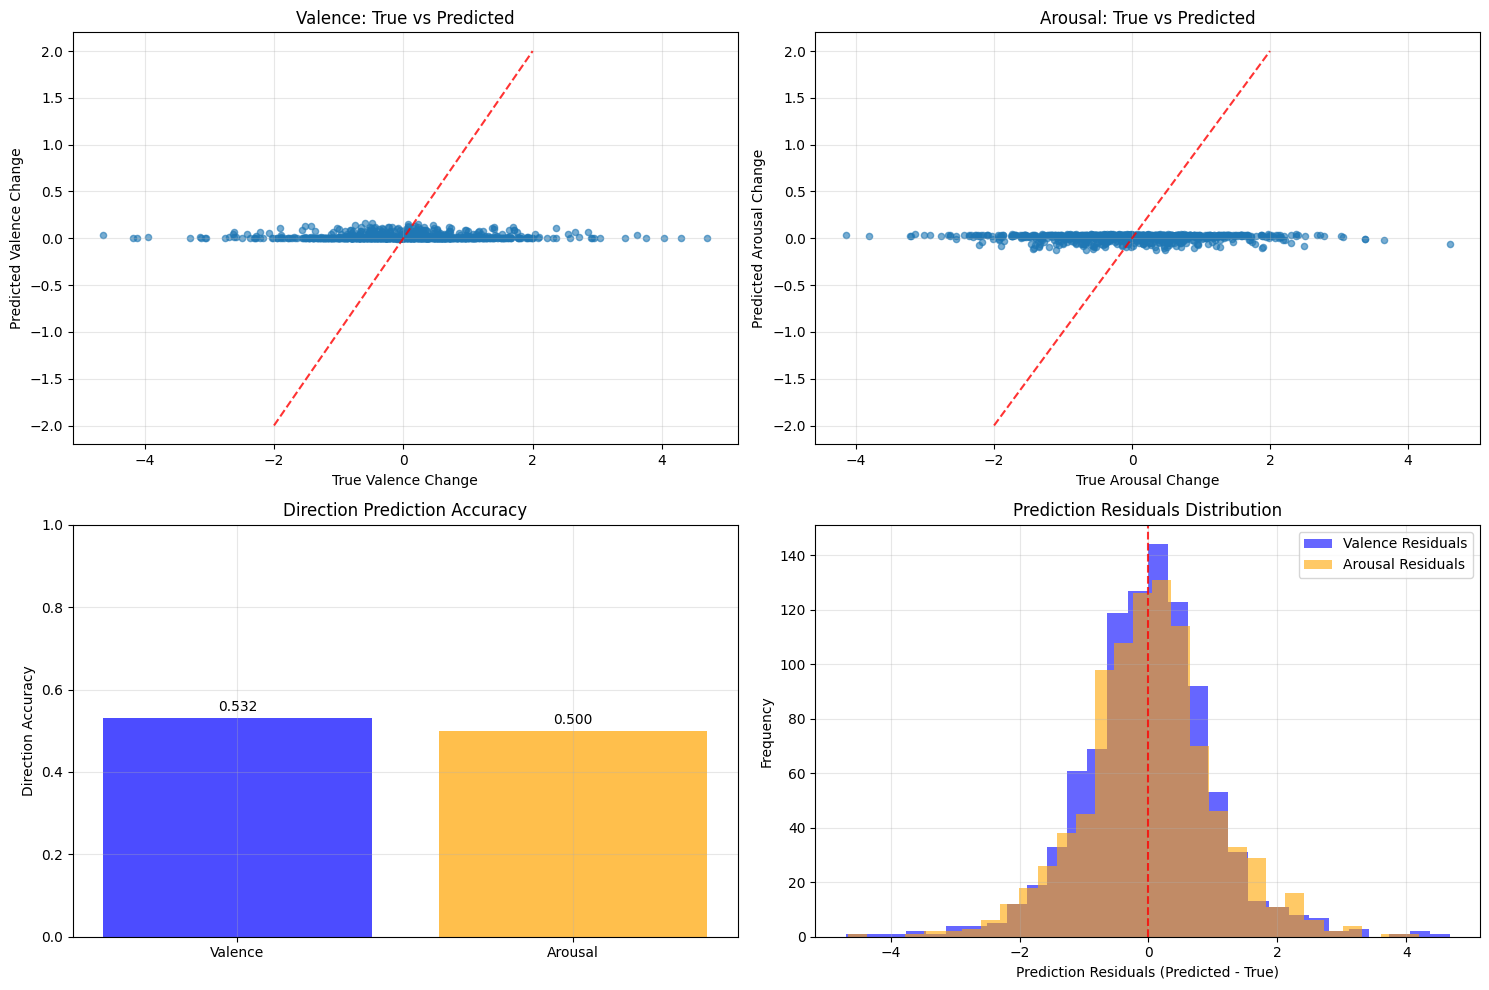

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Scatter plot: True vs Predicted
ax1.scatter(y_true_deltas[:, 0], y_pred_deltas[:, 0], alpha=0.6, s=20)
ax1.plot([-2, 2], [-2, 2], 'r--', alpha=0.8)
ax1.set_xlabel('True Valence Change')
ax1.set_ylabel('Predicted Valence Change')
ax1.set_title('Valence: True vs Predicted')
ax1.grid(True, alpha=0.3)

ax2.scatter(y_true_deltas[:, 1], y_pred_deltas[:, 1], alpha=0.6, s=20)
ax2.plot([-2, 2], [-2, 2], 'r--', alpha=0.8)
ax2.set_xlabel('True Arousal Change')
ax2.set_ylabel('Predicted Arousal Change')
ax2.set_title('Arousal: True vs Predicted')
ax2.grid(True, alpha=0.3)

# Direction accuracy visualization
directions = ['Valence', 'Arousal']
accuracies = [comprehensive_results['direction_acc_v'], comprehensive_results['direction_acc_a']]

bars = ax3.bar(directions, accuracies, color=['blue', 'orange'], alpha=0.7)
ax3.set_ylabel('Direction Accuracy')
ax3.set_title('Direction Prediction Accuracy')
ax3.set_ylim(0, 1)
ax3.grid(True, alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc:.3f}', ha='center', va='bottom')

# Residual analysis
residuals_v = y_pred_deltas[:, 0] - y_true_deltas[:, 0]
residuals_a = y_pred_deltas[:, 1] - y_true_deltas[:, 1]

ax4.hist(residuals_v, bins=30, alpha=0.6, label='Valence Residuals', color='blue')
ax4.hist(residuals_a, bins=30, alpha=0.6, label='Arousal Residuals', color='orange')
ax4.axvline(0, color='red', linestyle='--', alpha=0.8)
ax4.set_xlabel('Prediction Residuals (Predicted - True)')
ax4.set_ylabel('Frequency')
ax4.set_title('Prediction Residuals Distribution')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

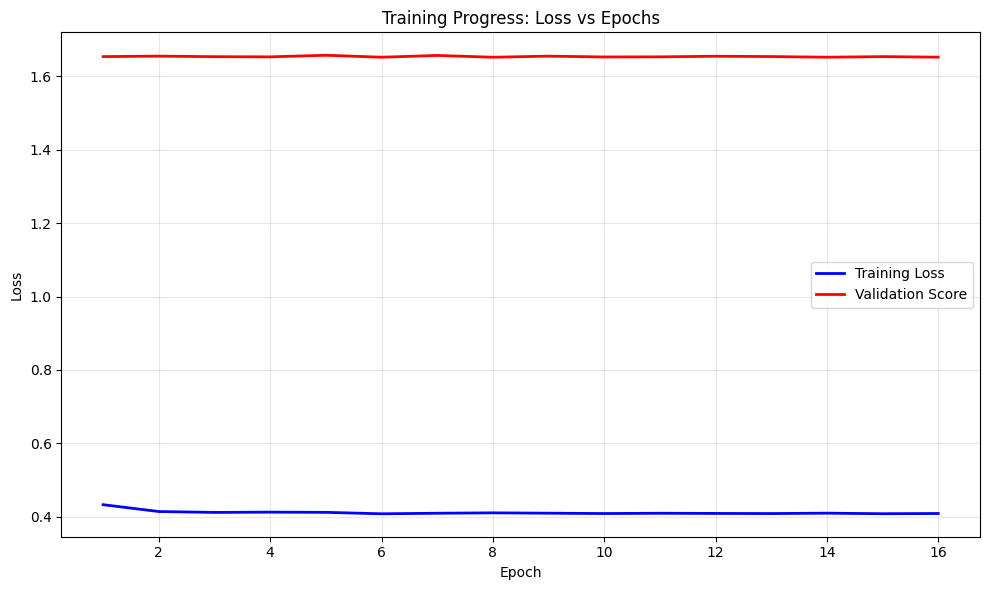

In [25]:
# Training and Validation Loss
plt.figure(figsize=(10, 6))
epochs_range = range(1, len(train_losses) + 1)
plt.plot(epochs_range, train_losses, 'b-', label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_scores, 'r-', label='Validation Score', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress: Loss vs Epochs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

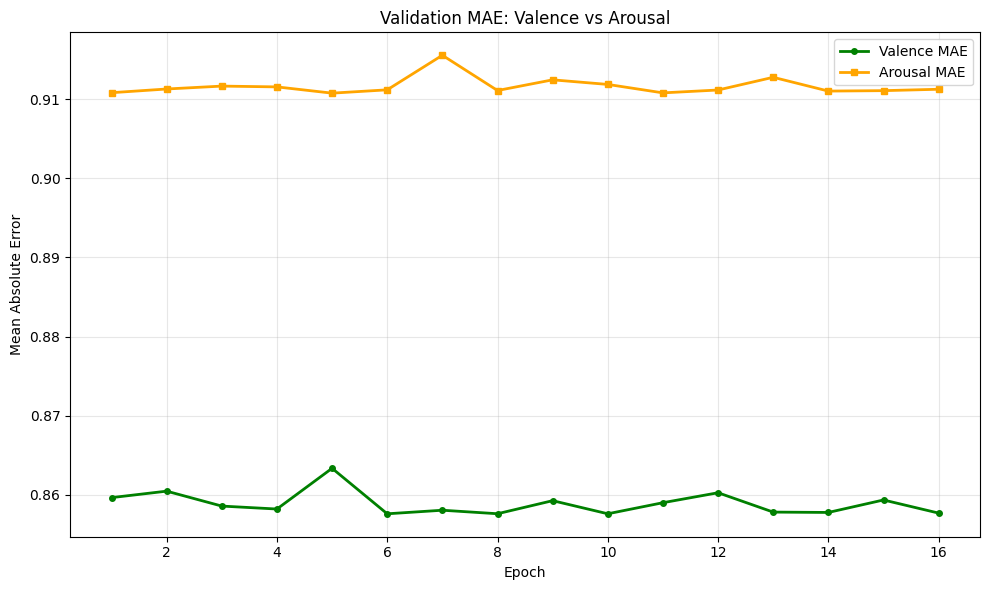

In [26]:
# Validation MAE for Valence and Arousal
plt.figure(figsize=(10, 6))
epochs_range = range(1, len(val_maes_v) + 1)
plt.plot(epochs_range, val_maes_v, 'g-', label='Valence MAE', linewidth=2, marker='o', markersize=4)
plt.plot(epochs_range, val_maes_a, 'orange', label='Arousal MAE', linewidth=2, marker='s', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.title('Validation MAE: Valence vs Arousal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

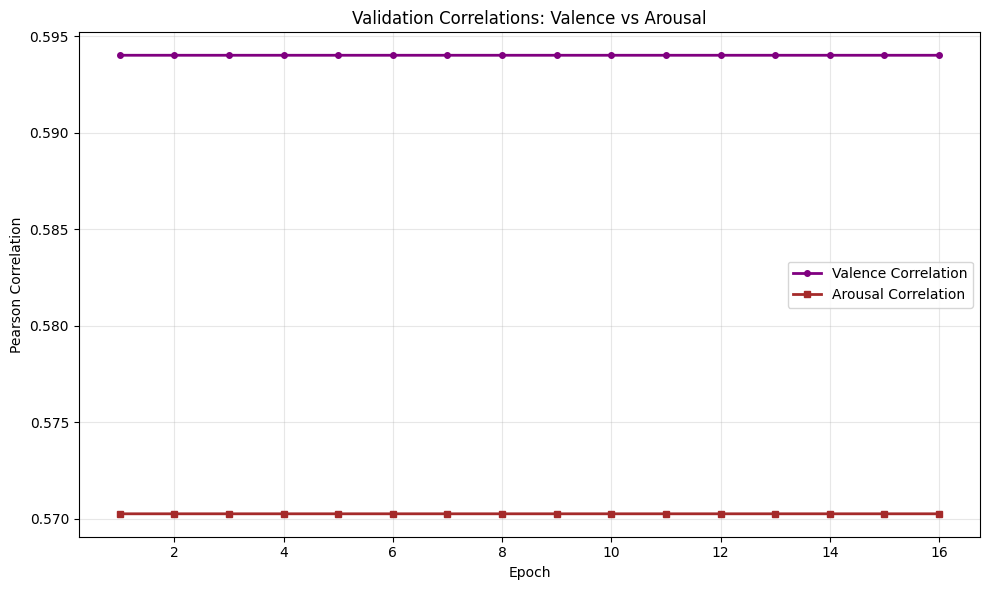

In [27]:
# Validation Correlations for Valence and Arousal
plt.figure(figsize=(10, 6))
epochs_range = range(1, len(val_corrs_v) + 1)
plt.plot(epochs_range, val_corrs_v, 'purple', label='Valence Correlation', linewidth=2, marker='o', markersize=4)
plt.plot(epochs_range, val_corrs_a, 'brown', label='Arousal Correlation', linewidth=2, marker='s', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Pearson Correlation')
plt.title('Validation Correlations: Valence vs Arousal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Persistence  MAE v=0.757 a=0.777 | r_v=0.597 r_a=0.585


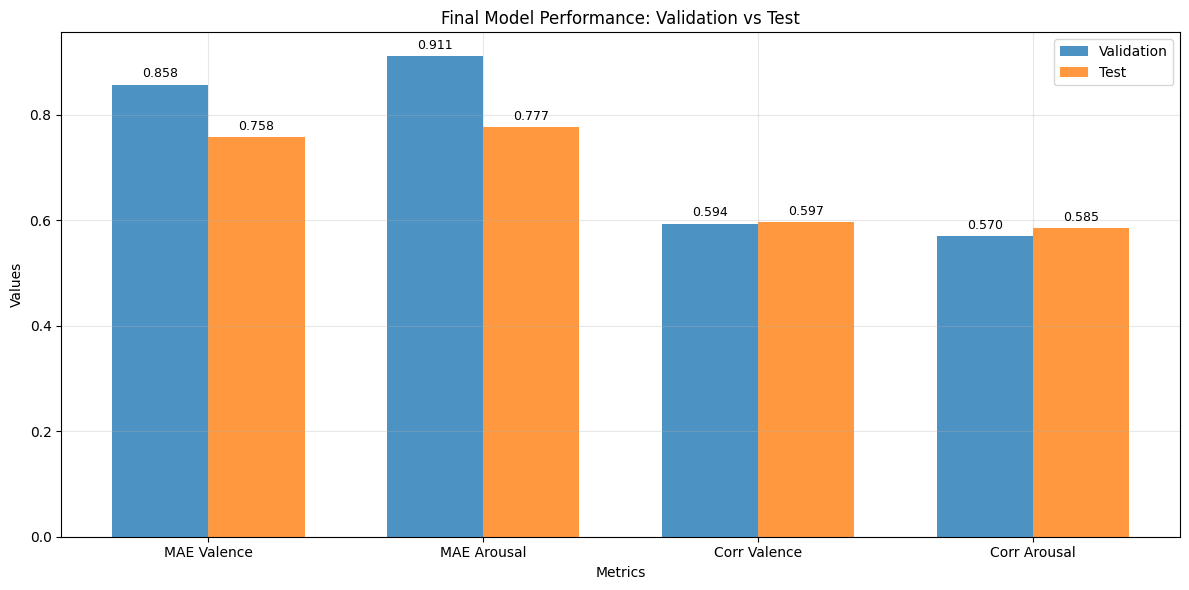

In [ ]:
# Get persistence baseline results first
persistence_test = persistence_baseline(test_dl)

# Create comparison bar plot
metrics = ['MAE Valence', 'MAE Arousal', 'Corr Valence', 'Corr Arousal']
val_final = [val_maes_v[-1], val_maes_a[-1], val_corrs_v[-1], val_corrs_a[-1]]
test_final = [test_m['mae_valence'], test_m['mae_arousal'], test_m['r_valence'], test_m['r_arousal']]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, val_final, width, label='Validation', alpha=0.8)
bars2 = ax.bar(x + width/2, test_final, width, label='Test', alpha=0.8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Values')
ax.set_title('Final Model Performance: Validation vs Test')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

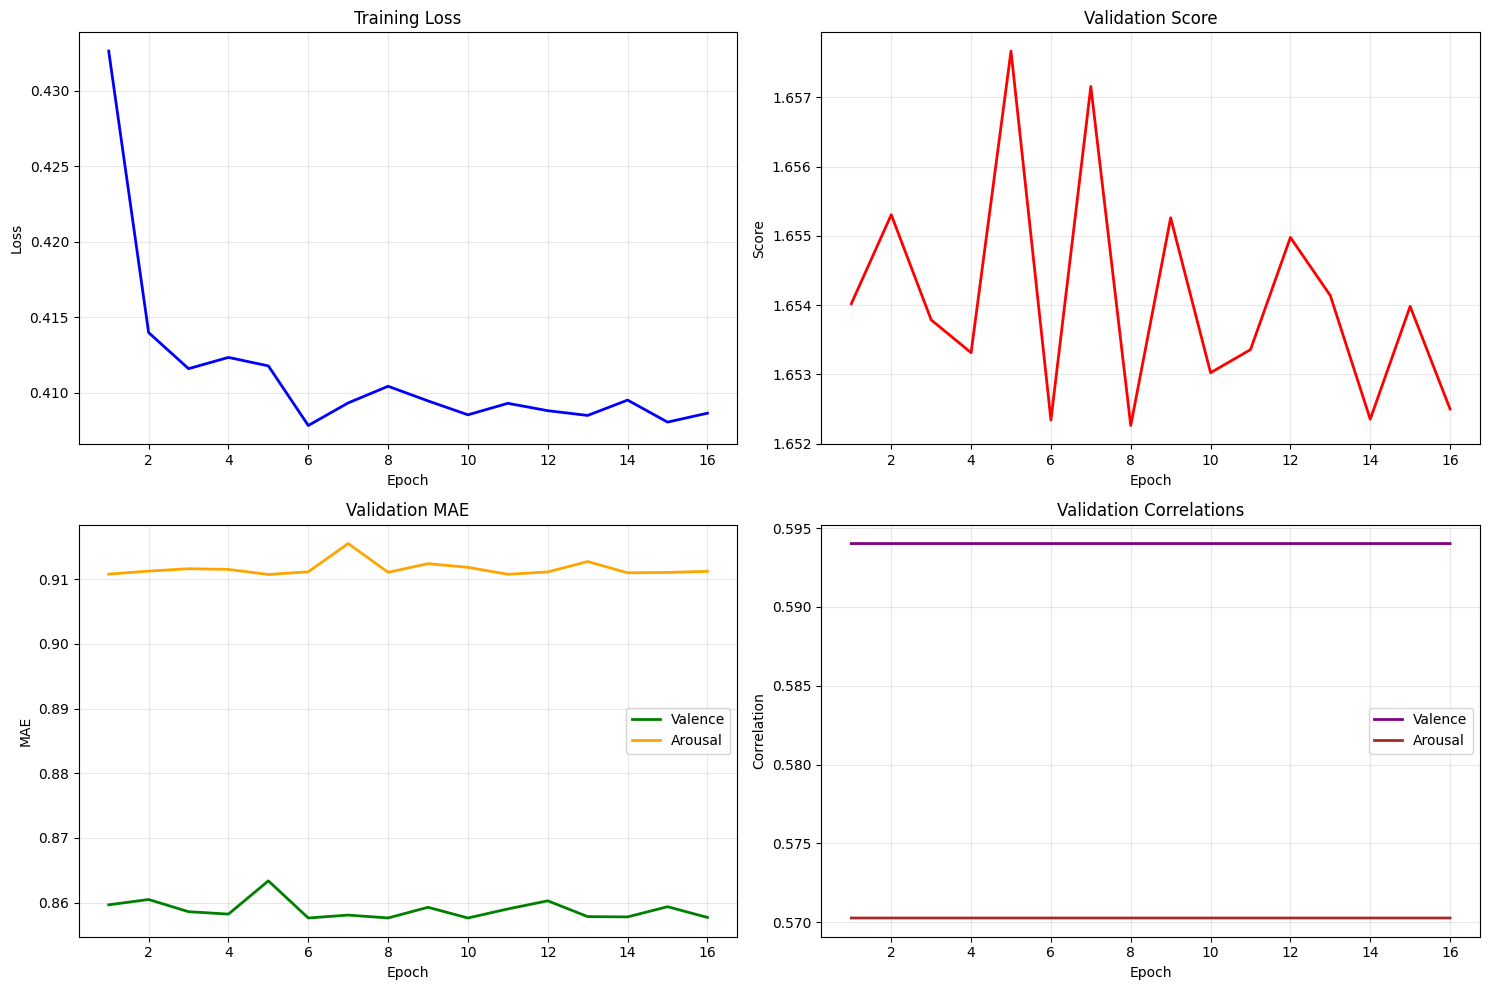

In [29]:
# Learning Curves Summary
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

epochs_range = range(1, len(train_losses) + 1)

# Training loss
ax1.plot(epochs_range, train_losses, 'b-', linewidth=2)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

# Validation score
ax2.plot(epochs_range, val_scores, 'r-', linewidth=2)
ax2.set_title('Validation Score')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.grid(True, alpha=0.3)

# MAE comparison
ax3.plot(epochs_range, val_maes_v, 'g-', label='Valence', linewidth=2)
ax3.plot(epochs_range, val_maes_a, 'orange', label='Arousal', linewidth=2)
ax3.set_title('Validation MAE')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('MAE')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Correlation comparison
ax4.plot(epochs_range, val_corrs_v, 'purple', label='Valence', linewidth=2)
ax4.plot(epochs_range, val_corrs_a, 'brown', label='Arousal', linewidth=2)
ax4.set_title('Validation Correlations')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Correlation')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


=== TESTING CIRCUMPLEX FEATURES (14 features) ===
circumplex: VAL MAE=1.698, TEST MAE=1.475

=== TESTING ROBERTA FEATURES (17 features) ===
roberta: VAL MAE=1.697, TEST MAE=1.473

=== TESTING FUSION FEATURES (55 features) ===
fusion: VAL MAE=1.698, TEST MAE=1.474

=== TESTING MINIMAL FEATURES (5 features) ===
minimal: VAL MAE=1.698, TEST MAE=1.473

=== FEATURE SET COMPARISON ===
           n_features test_mae_sum test_r_mean
circumplex         14     1.475075    0.605617
roberta            17      1.47334     0.60646
fusion             55     1.473558    0.606648
minimal             5     1.473009    0.606657


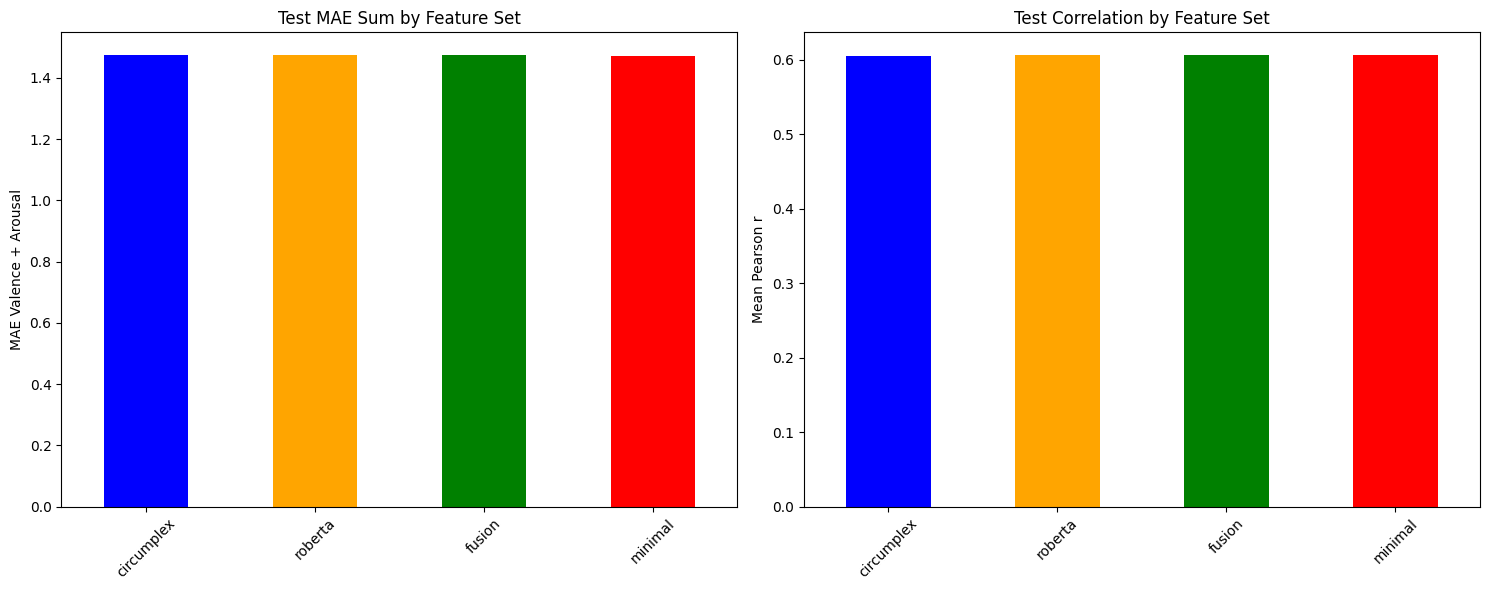

In [ ]:
def feature_ablation():
    """compare feature sets"""
    
    feature_sets = {
        'circumplex': circ_feats,
        'roberta': roberta_feats, 
        'fusion': fusion_feats,
        'minimal': ['v_true_mean', 'a_true_mean', 'v_true_mean_delta', 'a_true_mean_delta', 'posts']
    }
    
    ablation_results = {}
    
    for feat_name, feats in feature_sets.items():
        if not feats:
            continue
            
        print(f"\n=== TESTING {feat_name.upper()} FEATURES ({len(feats)} features) ===")
        
        # Build sequences for this feature set
        X_feat, y_feat, y_last_feat, meta_feat = build_sequences(df, feats, TARGET, HIST_L, LAG)
        
        # Split data
        idx_tr = meta_feat["user_id"].isin(train_u).values
        idx_va = meta_feat["user_id"].isin(val_u).values  
        idx_te = meta_feat["user_id"].isin(test_u).values
        
        X_tr_f = X_feat[idx_tr]; X_va_f = X_feat[idx_va]; X_te_f = X_feat[idx_te]
        y_tr_f = y_feat[idx_tr]; y_va_f = y_feat[idx_va]; y_te_f = y_feat[idx_te]
        y_last_tr_f = y_last_feat[idx_tr]; y_last_va_f = y_last_feat[idx_va]; y_last_te_f = y_last_feat[idx_te]
        
        # Scale
        mu_X_f = X_tr_f.mean(axis=(0,1), keepdims=True)
        sd_X_f = X_tr_f.std(axis=(0,1), keepdims=True) + 1e-6
        X_tr_f = (X_tr_f - mu_X_f) / sd_X_f
        X_va_f = (X_va_f - mu_X_f) / sd_X_f
        X_te_f = (X_te_f - mu_X_f) / sd_X_f
        
        sd_y_f = y_tr_f.std(axis=0, keepdims=True) + 1e-6
        y_tr_f = y_tr_f / sd_y_f; y_va_f = y_va_f / sd_y_f; y_te_f = y_te_f / sd_y_f
        
        # Best parameters from full fusion model
        best_config = {'hidden_size': 128, 'num_layers': 1, 'dropout': 0.15, 'lr': 2e-3}
        
        # Train best model
        model_f = LSTM(d_in=X_tr_f.shape[2], **{k:v for k,v in best_config.items() if k != 'lr'}).to(device)
        opt_f = optim.AdamW(model_f.parameters(), lr=best_config['lr'], weight_decay=WD)
        
        # Training loop
        train_dl_f = make_loader(X_tr_f, y_tr_f, y_last_tr_f, batch=BATCH_TR, shuffle=True)
        val_dl_f = make_loader(X_va_f, y_va_f, y_last_va_f, batch=BATCH_EVAL, shuffle=False)
        test_dl_f = make_loader(X_te_f, y_te_f, y_last_te_f, batch=BATCH_EVAL, shuffle=False)
        
        huber_f = nn.SmoothL1Loss()
        best_f = {"score": float("inf"), "state": None, "val": None}
        
        for epoch in range(1, 21):  # Reduced epochs for ablation
            model_f.train()
            for xb, yb_delta, yb_last in train_dl_f:
                xb, yb_delta = xb.to(device), yb_delta.to(device)
                opt_f.zero_grad(set_to_none=True)
                d_pred = model_f(xb)
                loss = 0.95*huber_f(d_pred, yb_delta) + 0.05*corr_loss(d_pred, yb_delta)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model_f.parameters(), 1.0)
                opt_f.step()
            
            # Validation
            val_m_f = eval_loader(val_dl_f, model_f, sd_y_f, device)
            val_score_f = val_score(val_m_f)
            
            if val_score_f < best_f["score"]:
                best_f = {"score": val_score_f, "state": {k:v.cpu().clone() for k,v in model_f.state_dict().items()}, "val": val_m_f}
        
        # Test evaluation
        model_f.load_state_dict(best_f["state"])
        test_m_f = eval_loader(test_dl_f, model_f, sd_y_f, device)
        
        ablation_results[feat_name] = {
            'n_features': len(feats),
            'val_mae_sum': best_f["val"]["mae_valence"] + best_f["val"]["mae_arousal"],
            'val_r_mean': (best_f["val"]["r_valence"] + best_f["val"]["r_arousal"]) / 2,
            'test_mae_sum': test_m_f["mae_valence"] + test_m_f["mae_arousal"],
            'test_r_mean': (test_m_f["r_valence"] + test_m_f["r_arousal"]) / 2,
            'details': test_m_f
        }
        
        print(f"{feat_name}: VAL MAE={ablation_results[feat_name]['val_mae_sum']:.3f}, TEST MAE={ablation_results[feat_name]['test_mae_sum']:.3f}")
    
    return ablation_results

ablation_results = feature_ablation()

results_df = pd.DataFrame(ablation_results).T
print("\n=== FEATURE SET COMPARISON ===")
print(results_df[['n_features', 'test_mae_sum', 'test_r_mean']].round(3))

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# MAE comparison
results_df['test_mae_sum'].plot(kind='bar', ax=ax1, color=['blue', 'orange', 'green', 'red'])
ax1.set_title('Test MAE Sum by Feature Set')
ax1.set_ylabel('MAE Valence + Arousal')
ax1.tick_params(axis='x', rotation=45)

# Correlation comparison  
results_df['test_r_mean'].plot(kind='bar', ax=ax2, color=['blue', 'orange', 'green', 'red'])
ax2.set_title('Test Correlation by Feature Set')
ax2.set_ylabel('Mean Pearson r')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
def temporal_split_comparison():
    """Compare user-level vs temporal splits"""
    
    print("\n=== TEMPORAL SPLIT COMPARISON ===")
    
    # Temporal split based on weeks
    df_sorted = df.sort_values(['user_id', 'week'])
    split_week = df['week'].quantile(0.7)
    val_week = df['week'].quantile(0.85)
    
    train_df_temp = df[df['week'] <= split_week]
    val_df_temp = df[(df['week'] > split_week) & (df['week'] <= val_week)]
    test_df_temp = df[df['week'] > val_week]
    
    print(f"Temporal split dates:")
    print(f"  Train: up to {split_week.strftime('%Y-%m-%d')}")
    print(f"  Val: {split_week.strftime('%Y-%m-%d')} to {val_week.strftime('%Y-%m-%d')}")  
    print(f"  Test: after {val_week.strftime('%Y-%m-%d')}")
    
    # Build sequences for temporal split
    X_temp, y_temp, y_last_temp, meta_temp = build_sequences(df, fusion_feats, TARGET, HIST_L, LAG)
    
    # Create temporal indices
    temp_train_weeks = set(train_df_temp['week'])
    temp_val_weeks = set(val_df_temp['week']) 
    temp_test_weeks = set(test_df_temp['week'])
    
    idx_tr_temp = meta_temp["end_week"].isin(temp_train_weeks).values
    idx_va_temp = meta_temp["end_week"].isin(temp_val_weeks).values
    idx_te_temp = meta_temp["end_week"].isin(temp_test_weeks).values
    
    print(f"Temporal split sizes: Train={idx_tr_temp.sum()}, Val={idx_va_temp.sum()}, Test={idx_te_temp.sum()}")
    
    # Train quick model on temporal split
    X_tr_temp = X_temp[idx_tr_temp]; y_tr_temp = y_temp[idx_tr_temp]; y_last_tr_temp = y_last_temp[idx_tr_temp]
    X_va_temp = X_temp[idx_va_temp]; y_va_temp = y_temp[idx_va_temp]; y_last_va_temp = y_last_temp[idx_va_temp]
    X_te_temp = X_temp[idx_te_temp]; y_te_temp = y_temp[idx_te_temp]; y_last_te_temp = y_last_temp[idx_te_temp]
    
    # Scale temporal data
    mu_X_temp = X_tr_temp.mean(axis=(0,1), keepdims=True)
    sd_X_temp = X_tr_temp.std(axis=(0,1), keepdims=True) + 1e-6
    X_tr_temp = (X_tr_temp - mu_X_temp) / sd_X_temp
    X_va_temp = (X_va_temp - mu_X_temp) / sd_X_temp  
    X_te_temp = (X_te_temp - mu_X_temp) / sd_X_temp
    
    sd_y_temp = y_tr_temp.std(axis=0, keepdims=True) + 1e-6
    y_tr_temp /= sd_y_temp; y_va_temp /= sd_y_temp; y_te_temp /= sd_y_temp
    
    # Train temporal model
    model_temp = LSTM(d_in=X_tr_temp.shape[2], hidden_size=128, num_layers=2, dropout=0.15).to(device)
    opt_temp = optim.AdamW(model_temp.parameters(), lr=2e-3, weight_decay=WD)
    
    train_dl_temp = make_loader(X_tr_temp, y_tr_temp, y_last_tr_temp, batch=BATCH_TR, shuffle=True)
    val_dl_temp = make_loader(X_va_temp, y_va_temp, y_last_va_temp, batch=BATCH_EVAL, shuffle=False)
    test_dl_temp = make_loader(X_te_temp, y_te_temp, y_last_te_temp, batch=BATCH_EVAL, shuffle=False)
    
    huber_temp = nn.SmoothL1Loss()
    best_temp = {"score": float("inf"), "state": None}
    
    for epoch in range(1, 16):
        model_temp.train()
        for xb, yb_delta, yb_last in train_dl_temp:
            xb, yb_delta = xb.to(device), yb_delta.to(device)
            opt_temp.zero_grad(set_to_none=True)
            d_pred = model_temp(xb)
            loss = 0.95*huber_temp(d_pred, yb_delta) + 0.05*corr_loss(d_pred, yb_delta)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_temp.parameters(), 1.0)
            opt_temp.step()
        
        val_m_temp = eval_loader(val_dl_temp, model_temp, sd_y_temp, device)
        val_score_temp = val_score(val_m_temp)
        
        if val_score_temp < best_temp["score"]:
            best_temp = {"score": val_score_temp, "state": {k:v.cpu().clone() for k,v in model_temp.state_dict().items()}}
    
    # Test temporal model
    model_temp.load_state_dict(best_temp["state"])
    test_m_temp = eval_loader(test_dl_temp, model_temp, sd_y_temp, device)
    
    print(f"\nTemporal Split Results:")
    print(f"  Test MAE: V={test_m_temp['mae_valence']:.3f}, A={test_m_temp['mae_arousal']:.3f}")
    print(f"  Test Corr: V={test_m_temp['r_valence']:.3f}, A={test_m_temp['r_arousal']:.3f}")
    
    return test_m_temp

temporal_results = temporal_split_comparison()


=== TEMPORAL SPLIT COMPARISON ===
Temporal split dates:
  Train: up to 2023-02-13
  Val: 2023-02-13 to 2024-01-29
  Test: after 2024-01-29
Temporal split sizes: Train=4803, Val=1036, Test=981

Temporal Split Results:
  Test MAE: V=0.675, A=0.662
  Test Corr: V=0.579, A=0.567
